In [1]:
import pickle
import os



In [2]:
with open('mnist_data.pkl', 'rb') as file:
    data = pickle.load(file)

In [3]:
X_train = data['x_train']
y_train = data['y_train']
X_test = data['x_test']
y_test = data['y_test']

del data  # Free up memory

In [4]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

x_train = [x.flatten()*2 - 1 for x in X_train]
x_test  = [x.flatten()*2 - 1 for x in X_test]

del X_train, X_test  # Free up memory

In [5]:
mlp = MLPClassifier(hidden_layer_sizes=(128,64),max_iter=20, random_state=42, verbose=True)
mlp.fit(x_train, y_train)
y_pred = mlp.predict(x_test)




Iteration 1, loss = 0.44119201
Iteration 2, loss = 0.19549905
Iteration 3, loss = 0.14098127
Iteration 4, loss = 0.11095271
Iteration 5, loss = 0.09608072


/Users/jared.mcbride/Documents/Code Projects/venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


In [ ]:
mlp.score(x_test, y_test)

0.9759

In [32]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
y_pred = mlp.predict(x_test)
print(confusion_matrix(y_test, y_pred))

[[ 968    1    1    1    2    1    3    1    2    0]
 [   0 1124    3    2    0    1    2    0    3    0]
 [   2    4 1001    5    3    0    2    8    6    1]
 [   0    0    2  994    0    2    0    5    2    5]
 [   1    0    4    1  960    1    3    1    1   10]
 [   2    1    0   10    2  867    2    2    4    2]
 [   6    3    0    1    6    4  933    2    3    0]
 [   1    7    6    3    3    0    0  999    3    6]
 [   2    0    4    5    4    1    3    6  947    2]
 [   2    2    0    8   15    3    0    4    9  966]]


In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)
x_train_pca.shape


(60000, 50)

In [41]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)  # Retain 95% of variance
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)
x_train_pca.shape

(60000, 50)

In [42]:
pca.singular_values_

array([1108.16472368,  947.58579291,  883.53665319,  825.81935128,
        784.91909782,  738.69487475,  643.45185918,  604.09301886,
        591.19153869,  546.12732063,  516.62078314,  505.95401355,
        465.96113694,  462.73094208,  446.94675535,  433.18927735,
        409.40207079,  401.96853322,  387.6033456 ,  381.91712945,
        367.30472726,  356.91679121,  347.36904009,  339.81371855,
        334.34429102,  325.8949456 ,  320.66149094,  315.44703403,
        306.98304547,  295.67105517,  288.5745    ,  286.38555599,
        276.14300145,  272.44478344,  268.57134233,  262.27982085,
        252.98667201,  248.46261139,  246.81999495,  244.45985593,
        240.40963849,  237.25426618,  230.12430085,  224.47762223,
        220.71411285,  217.86604724,  214.02950948,  210.92745227,
        207.43913383,  201.81680426])

In [ ]:
# Low-rank approximation via PCA reconstruction
# Uses the already-fitted `pca` and raw flattened inputs `x_train` / `x_test`.
import numpy as np

# Ensure inputs are numpy arrays
Xtr = np.asarray(x_train)
Xte = np.asarray(x_test)

# Project to lower dimension (already done) and reconstruct back to original space
Xtr_recon = pca.inverse_transform(x_train_pca)
Xte_recon = pca.inverse_transform(x_test_pca)

# Report reconstruction error (MSE per sample)
tr_mse = np.mean((Xtr - Xtr_recon) ** 2)
te_mse = np.mean((Xte - Xte_recon) ** 2)

print("Train reconstruction MSE:", tr_mse)
print("Test reconstruction MSE:", te_mse)

# Example: use reconstructed inputs with the MLP
MLPPCA_recon = MLPClassifier(hidden_layer_sizes=(100), max_iter=30, verbose=False)
MLPPCA_recon.fit(Xtr_recon, y_train)
print("MLP on reconstructed train -> test accuracy:", MLPPCA_recon.score(Xte_recon, y_test))

In [43]:
MLPPCA = MLPClassifier(hidden_layer_sizes=(100), max_iter=30, verbose=True)
MLPPCA.fit(x_train_pca, y_train)

Iteration 1, loss = 0.59089585
Iteration 2, loss = 0.21838732
Iteration 3, loss = 0.16160582
Iteration 4, loss = 0.12985026
Iteration 5, loss = 0.10936740
Iteration 6, loss = 0.09479444
Iteration 7, loss = 0.08389561
Iteration 8, loss = 0.07546737
Iteration 9, loss = 0.06856122
Iteration 10, loss = 0.06295293
Iteration 11, loss = 0.05850205
Iteration 12, loss = 0.05408234
Iteration 13, loss = 0.05093021
Iteration 14, loss = 0.04765914
Iteration 15, loss = 0.04481295
Iteration 16, loss = 0.04234783
Iteration 17, loss = 0.03994083
Iteration 18, loss = 0.03773786
Iteration 19, loss = 0.03611361
Iteration 20, loss = 0.03410903
Iteration 21, loss = 0.03259526
Iteration 22, loss = 0.03081036
Iteration 23, loss = 0.02938240
Iteration 24, loss = 0.02810152
Iteration 25, loss = 0.02662161
Iteration 26, loss = 0.02574259
Iteration 27, loss = 0.02449161
Iteration 28, loss = 0.02326141
Iteration 29, loss = 0.02243104
Iteration 30, loss = 0.02130773


/Users/jared.mcbride/Documents/Code Projects/venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=100, max_iter=30, verbose=True)

In [44]:
MLPPCA.score(x_test_pca, y_test)

0.9784

In [45]:
y_pred_pca = MLPPCA.predict(x_test_pca)
print(confusion_matrix(y_test, y_pred_pca))
print(confusion_matrix(y_test, y_pred))

[[ 968    1    1    0    2    1    1    0    4    2]
 [   0 1128    1    1    0    1    2    0    2    0]
 [   1    0 1009    3    2    0    2    5   10    0]
 [   1    0    4  993    0    4    0    2    5    1]
 [   1    0    4    0  960    1    5    0    0   11]
 [   3    1    0   14    1  859    5    2    5    2]
 [   5    2    0    2    5    4  936    2    2    0]
 [   0    4    7    3    1    1    0 1001    1   10]
 [   3    0    2    5    2    4    2    4  948    4]
 [   2    2    0    4    6    3    1    4    5  982]]
[[ 968    1    1    1    2    1    3    1    2    0]
 [   0 1124    3    2    0    1    2    0    3    0]
 [   2    4 1001    5    3    0    2    8    6    1]
 [   0    0    2  994    0    2    0    5    2    5]
 [   1    0    4    1  960    1    3    1    1   10]
 [   2    1    0   10    2  867    2    2    4    2]
 [   6    3    0    1    6    4  933    2    3    0]
 [   1    7    6    3    3    0    0  999    3    6]
 [   2    0    4    5    4    1    3    6  94

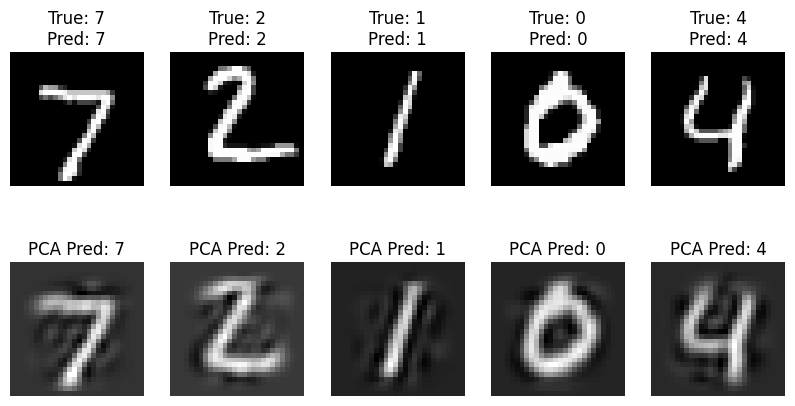

In [48]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(5):
    axes[0, i].imshow(X_test[i], cmap='gray')
    axes[0, i].set_title(f"True: {y_test[i]}\nPred: {y_pred[i]}")
    axes[0, i].axis('off')

    recon_img = pca.inverse_transform(x_test_pca[i]).reshape(28, 28)
    axes[1, i].imshow(recon_img, cmap='gray')
    axes[1, i].set_title(f"PCA Pred: {y_pred_pca[i]}")
    axes[1, i].axis('off')

In [49]:
MLPPCA = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=30, verbose=True)
MLPPCA.fit(x_train_pca, y_train)

Iteration 1, loss = 0.41488332
Iteration 2, loss = 0.14503351
Iteration 2, loss = 0.14503351
Iteration 3, loss = 0.10278363
Iteration 3, loss = 0.10278363
Iteration 4, loss = 0.07987864
Iteration 4, loss = 0.07987864
Iteration 5, loss = 0.06597377
Iteration 5, loss = 0.06597377
Iteration 6, loss = 0.05579844
Iteration 6, loss = 0.05579844
Iteration 7, loss = 0.04814279
Iteration 7, loss = 0.04814279
Iteration 8, loss = 0.04131613
Iteration 8, loss = 0.04131613
Iteration 9, loss = 0.03583513
Iteration 9, loss = 0.03583513
Iteration 10, loss = 0.03127097
Iteration 10, loss = 0.03127097
Iteration 11, loss = 0.02752938
Iteration 11, loss = 0.02752938
Iteration 12, loss = 0.02479503
Iteration 12, loss = 0.02479503
Iteration 13, loss = 0.02188762
Iteration 13, loss = 0.02188762
Iteration 14, loss = 0.01898886
Iteration 14, loss = 0.01898886
Iteration 15, loss = 0.01717789
Iteration 15, loss = 0.01717789
Iteration 16, loss = 0.01414664
Iteration 16, loss = 0.01414664
Iteration 17, loss = 0.01

/Users/jared.mcbride/Documents/Code Projects/venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=30, verbose=True)

In [50]:
MLPPCA.score(x_test_pca, y_test)

0.9784